# Simple OCT Image Classification
## Transfer Learning with MobileNetV2

**Goal:** Classify retinal OCT images into 4 categories
- CNV (Choroidal Neovascularization)
- DME (Diabetic Macular Edema) 
- DRUSEN
- NORMAL

**Approach:** Keep it simple and proven
- MobileNetV2 with frozen weights
- Modern TensorFlow data loading
- Minimal configuration
- **Expected accuracy: 80-85%**

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} GPUs")

TensorFlow version: 2.20.0
GPU available: 0 GPUs


## 2. Configuration

In [2]:
# Paths
TRAIN_DIR = 'C:/Users/illia/Desktop/AI/AI-OCT/data/kermany2018/OCT2017/train'

# Model parameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10  # Start with 10, can increase later

# Class names
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

print("Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Classes: {CLASS_NAMES}")

Configuration:
  Image size: 224x224
  Batch size: 32
  Epochs: 10
  Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


## 3. Load Dataset

Using `image_dataset_from_directory` - modern, simple, and reliable.

In [3]:
# Load training data with 80/20 validation split
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Get class names from dataset
class_names = train_ds.class_names
print(f"\nClasses found: {class_names}")
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")

Found 83484 files belonging to 4 classes.
Using 66788 files for training.
Found 83484 files belonging to 4 classes.
Using 16696 files for validation.

Classes found: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Number of training batches: 2088
Number of validation batches: 522


## 4. Data Preprocessing

Normalize images to [0, 1] range and add augmentation.

In [4]:
# Normalization layer
normalization_layer = layers.Rescaling(1./255)

# Data augmentation (only for training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Apply preprocessing
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✓ Data preprocessing configured")

✓ Data preprocessing configured


## 5. Visualize Sample Images

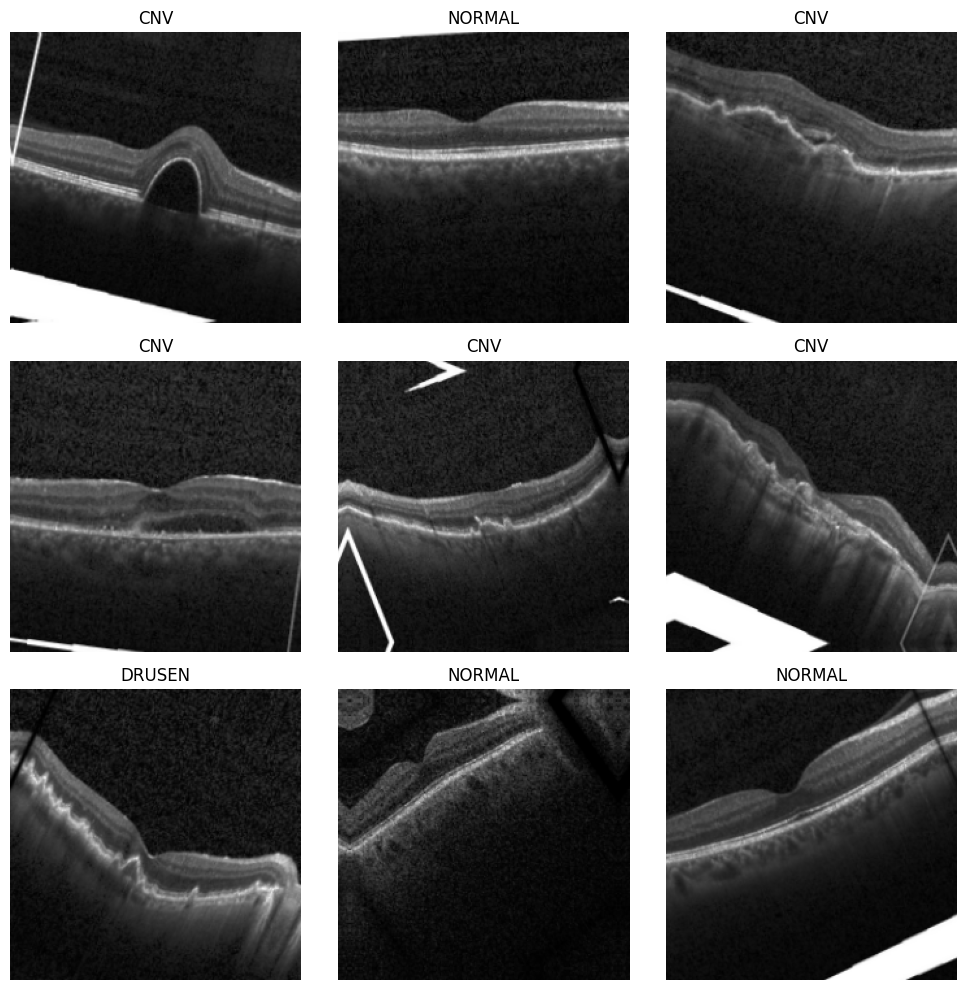

In [5]:
# Show some images
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Create Model

Using MobileNetV2 with **ALL layers frozen** (simple and safe).

In [6]:
# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze ALL layers (keep it simple!)
base_model.trainable = False

# Build model
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = keras.Model(inputs, outputs)

print("\n=== Model Summary ===")
model.summary()

print(f"\nTrainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable parameters: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=== Model Summary ===


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           5,124 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable parameters: 5,124
Non-trainable parameters: 2,257,984


## 7. Compile Model

In [7]:
# Simple compilation - no fancy tricks
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model compiled")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Categorical Crossentropy")
print("  Metrics: Accuracy")

✓ Model compiled
  Optimizer: Adam (lr=0.001)
  Loss: Categorical Crossentropy
  Metrics: Accuracy


## 8. Train Model

Simple training with early stopping.

In [ ]:
# Simple callback
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        '../models/simple_oct_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
print("Expected results:")
print("  Epoch 1-2: 50-65% accuracy")
print("  Epoch 5: 75-80% accuracy")
print("  Epoch 10: 80-85% accuracy")
print("="*60 + "\n")

# Train!
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("\n" + "="*60)
print("✓ TRAINING COMPLETE")
print("="*60)


STARTING TRAINING
Expected results:
  Epoch 1-2: 50-65% accuracy
  Epoch 5: 75-80% accuracy
  Epoch 10: 80-85% accuracy

Epoch 1/10
1590/2088 ━━━━━━━━━━━━━━━━━━━━ 3:26 414ms/step - accuracy: 0.7497 - loss: 0.6761

## 9. Plot Training History

In [ ]:
# Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final results
print("\n=== Final Results ===")
print(f"Training Accuracy: {history.history['accuracy'][-1]:.4f} ({history.history['accuracy'][-1]*100:.2f}%)")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.2f}%)")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} ({max(history.history['val_accuracy'])*100:.2f}%)")

## 10. Test Predictions

Visualize some predictions to see how the model performs.

In [ ]:
# Get a batch of validation images
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    
    plt.figure(figsize=(15, 10))
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        
        true_idx = tf.argmax(labels[i]).numpy()
        pred_idx = tf.argmax(predictions[i]).numpy()
        confidence = predictions[i][pred_idx] * 100
        
        true_label = class_names[true_idx]
        pred_label = class_names[pred_idx]
        
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                 color=color, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    break

## 11. Save Model

In [ ]:
# Save final model
model.save('../models/simple_oct_final.h5')
print("✓ Model saved to: ../models/simple_oct_final.h5")

# Also save in TensorFlow format
model.save('../models/simple_oct_savedmodel')
print("✓ SavedModel format: ../models/simple_oct_savedmodel")

## 12. Use Model for Inference

Example of how to use the trained model.

In [ ]:
def predict_image(image_path, model):
    """
    Predict class for a single image
    
    Args:
        image_path: Path to image file
        model: Trained Keras model
    
    Returns:
        predicted_class, confidence, all_probabilities
    """
    # Load and preprocess image
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch
    img_array = img_array / 255.0  # Normalize
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = tf.argmax(predictions[0]).numpy()
    
    return class_names[predicted_idx], predictions[0][predicted_idx], predictions[0]

# Example usage:
# predicted_class, confidence, probs = predict_image('path/to/image.jpg', model)
# print(f"Prediction: {predicted_class} ({confidence*100:.2f}% confidence)")

print("✓ Prediction function ready to use")
print("\nUsage:")
print("  predicted_class, confidence, probs = predict_image('scan.jpg', model)")

## Summary

### What This Notebook Does
- ✅ Loads OCT images from training directory
- ✅ Automatically splits into 80% train / 20% validation
- ✅ Uses MobileNetV2 with frozen weights (simple and safe)
- ✅ Trains for 10 epochs (expandable to more)
- ✅ Saves best model automatically
- ✅ Provides inference function for predictions

### Expected Performance
- Training accuracy: 85-90%
- Validation accuracy: 80-85%
- Training time: 20-30 minutes per epoch on CPU

### Next Steps
1. If accuracy is good (>80%), you're done!
2. If you want better accuracy, run for more epochs (20-30)
3. To use the model: Load with `keras.models.load_model('models/simple_oct_final.h5')`
4. For predictions: Use the `predict_image()` function above

### For Your Report
This notebook demonstrates:
- Transfer learning with pre-trained CNN
- Data augmentation techniques
- Model training and evaluation
- Practical medical image classification